# Problem - Minimum Number of Conference Rooms

Given an array of meeting time intervals intervals where intervals[i] = [starti, endi], return the minimum number of conference rooms required.

**Input**: `intervals = [[0,30],[5,10],[15,20]]`

**Output**: `2`

# ✅ Pattern: Line Sweep / Timeline Events using Prefix Sum

This technique converts each meeting into two “events”:
* **Start time = +1 room needed**
* **End time = -1 room needed** (a room freed)

Then we **walk the timeline in sorted order**, applying the increments and decrements while tracking:
* `current_rooms` → rooms currently occupied
* `max_rooms` → maximum of current_rooms over time ⇒ final answer

This is identical to **prefix-sum accumulation on a sorted map**.

# 🎯 Intuition

Imagine drawing all meetings along a timeline.
* Whenever a meeting **starts**, you need **one more room**.
* Whenever a meeting **ends**, one room is **freed**.

**🔥 But the key detail:**

If a meeting ends at time `t` and another starts at the same time `t`, **no extra room is needed** because the `-1` at time `t` is **processed** before the `+1`.

This happens automatically if we:
* Sort events by time
* If same time: process `-1` before `+1`

# 🧠 Technique (Step-by-Step)

**Step 1 — Build the Hash Map**

For each interval `[start, end]`:

```
map[start] = map[start] + 1   → meeting starts → need 1 more room
map[end]   = map[end] -1      → meeting ends   → release room
```

Example:

```
intervals = [[0,30],[5,10],[15,20]]

map = {
  0: +1,
  30: -1,
  5: +1,
  10: -1,
  15: +1,
  20: -1
}
```

**Step 2 — Traverse timeline in sorted order**

Sort the keys of the map.

```
times = [0, 5, 10, 15, 20, 30]
```

**Step 3 — Sweep the line and maintain running count**

Initialize:

```
current_rooms = 0
max_rooms = 0
```

Process one time at a time:

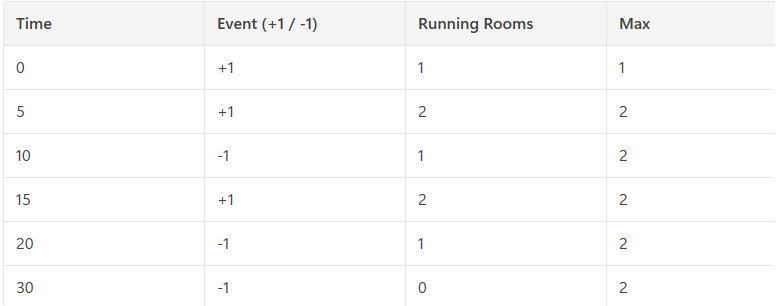

Final answer:

```
Minimum rooms = 2
```


# 🧩 Why this Works

This follows the **prefix-sum idea**:

```
rooms_at_time_t = sum of all (+1 and -1) events up to time t
```

The **maximum prefix value = maximum number of simultaneous meetings**.

Same principle as:
* Train platforms problem
* Product except self (prefix-suffix)
* Range addition (difference array)
* Line sweep algorithms in computational geometry

# Solution

In [1]:
def min_meeting_rooms(intervals):
    events = {}

    # Build event map
    for start, end in intervals:
        events[start] = events.get(start, 0) + 1
        events[end] = events.get(end, 0) - 1

    current_rooms = 0
    max_rooms = 0

    # Sweep through sorted times
    for time in sorted(events.keys()):
        current_rooms += events[time]
        max_rooms = max(max_rooms, current_rooms)

    return max_rooms


intervals = [[0,30],[5,10],[15,20]]
print(min_meeting_rooms(intervals))

2


# 🧠 Key Points to Remember

**✔ Line Sweep Pattern**

Convert intervals → events (+1, -1) → prefix sum.

**✔ Room Count Logic**
* Meeting starts → +1
* Meeting ends → -1

**✔ Sorted Order**

Walking sorted keys simulates real time.

**✔ Max overlap**

The highest accumulated value = answer.

# 🚀 Summary (One-Line Intuition)

* Turn each meeting into a **“+1 at start, –1 at end”** event,
* sweep the timeline,
* accumulate rooms like prefix sum,
* and the maximum value reached is the number of rooms needed.